In [16]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.metrics import classification_report,roc_auc_score,f1_score, accuracy_score,roc_curve, confusion_matrix,RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
import os
from tqdm import tqdm
os.chdir('/home/pgcp-ai/MachineLearning/Datasets/')

In [17]:
hr = pd.read_csv("HR_comma_sep.csv")

In [18]:
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [19]:
hr.isna().sum().sum()

0

In [20]:
X, y = hr.drop('left', axis = 1), hr['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 26,stratify=hr['left'])
y_train

7966     0
7440     0
1831     1
14588    1
13302    0
        ..
11699    0
11184    0
4490     0
7400     0
9559     0
Name: left, Length: 10496, dtype: int64

In [21]:
ohe = OneHotEncoder(sparse_output = False, drop = 'first').set_output(transform = 'pandas')
transformer = ColumnTransformer(transformers=[('OHE',ohe,make_column_selector(dtype_include=object)),
                                            ]
                               ,remainder='passthrough',
                               verbose_feature_names_out=False
                               ).set_output(transform='pandas')
X_train_trans = transformer.fit_transform(X_train)
X_test_trans = transformer.transform(X_test)

In [22]:
scores=[]
k=[1,2,3,4,5,6,7,8,9,10]
for i in k:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_trans,y_train)
    y_pred = knn.predict(X_test_trans)
    y_pred_prob = knn.predict_proba(X_test_trans)
    score = roc_auc_score(y_test,y_pred_prob[:,1])
    scores.append([i,score])

df_scores = pd.DataFrame(scores,columns=['k','scores'])
df_scores = df_scores.sort_values('scores',ascending=False)

In [23]:
bm = KNeighborsClassifier(n_neighbors=8)
bm.fit(X_train_trans,y_train)
y_pred = bm.predict(X_test_trans)
y_pred_prob = bm.predict_proba(X_test_trans)

In [24]:
fpr,tpr,thres = roc_curve(y_test,y_pred)

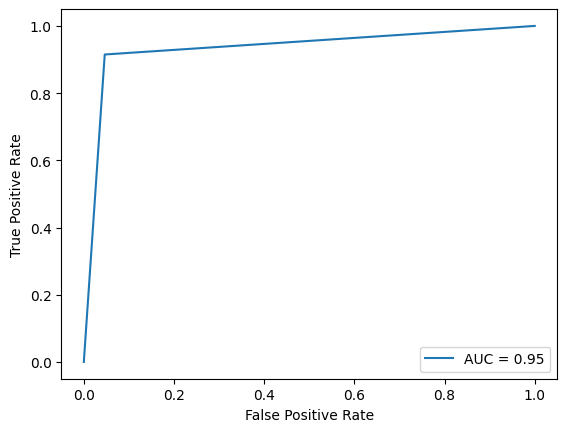

In [25]:
disp = RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=df_scores.loc[0,'scores'])
disp.plot()

##  K-NN

In [26]:
ss = StandardScaler()

In [30]:
Ks = [1,2,3,4,5,6,7]
scores = []
for k in tqdm(Ks):
    knn = KNeighborsClassifier(n_neighbors=k,n_jobs=-1)
    pipe = Pipeline([
        (
            "OHE",
            transformer
        ),
        (
            "SS",
            ss
        ),
        (
            'KNN',
            knn
        )
    ])
    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)
    scores.append([k,accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=['K','Score'])
df_scores.sort_values('Score',ascending=False)

100%|█████████████████████████████████████████████| 7/7 [00:01<00:00,  4.10it/s]


,K,Score
0,1,0.964437
1,2,0.960213
2,3,0.948211
3,4,0.946433
5,6,0.945099
4,5,0.941320
6,7,0.940876
